In [7]:
# ============================================================
# CELL 1: Import Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [8]:
# ============================================================
# CELL 2: Load Data + Basic Info
# ============================================================
path = r"C:\Users\admin\Downloads\Concrete compressive strength.csv"# update path if needed
df = pd.read_csv(path)

df.columns = df.columns.str.strip()  # clean column name whitespace (e.g. 'fine_aggregate ')

print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())

Shape: (1030, 9)

Head:
    cement  blast_furnace_slag  fly_ash  water  superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   coarse_aggregate  fine_aggregate  age  concrete_compressive_strength  
0            1040.0           676.0   28                          79.99  
1            1055.0           676.0   28                          61.89  
2             932.0           594.0  270                          40.27  
3             932.0           594.0  365                          41.05  
4             978.4           825.5  360                          44.30  

Dtypes:
 cement                           float64
blast_furnace_slag               float64
fly_ash                          flo

In [9]:
# ============================================================
# CELL 3: Clean Data — Nulls + FIXED (less destructive) Outlier Removal
# ============================================================
target_col = "concrete_compressive_strength"

print("Rows before cleaning:", df.shape[0])

# Handle nulls
if df.isnull().sum().sum() > 0:
    df = df.fillna(df.median(numeric_only=True))
print("Missing values after fill:", df.isnull().sum().sum())

# FIX #1: Do NOT run IQR on the target column — natural high/low strength
# values are real physics, not data errors.
# FIX #2: Widen the IQR multiplier from 1.5 -> 3.0 so we only cut TRUE
# extreme multivariate outliers instead of stripping valid high-cement /
# low-water / young-age combinations (which caused your manual-input miss).
def remove_outliers_iqr(data, cols, k=3.0):
    data = data.copy()
    mask = pd.Series(True, index=data.index)
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR
        mask &= (data[col] >= lower) & (data[col] <= upper)
    return data[mask]

rows_before = df.shape[0]
feature_cols = [c for c in df.columns if c != target_col]   # target excluded
df = remove_outliers_iqr(df, feature_cols, k=3.0)
rows_after = df.shape[0]

print("Rows before outlier removal:", rows_before)
print("Rows after outlier removal:", rows_after)
print("Rows removed:", rows_before - rows_after)

df = df.reset_index(drop=True)

Rows before cleaning: 1030
Missing values after fill: 0
Rows before outlier removal: 1030
Rows after outlier removal: 997
Rows removed: 33


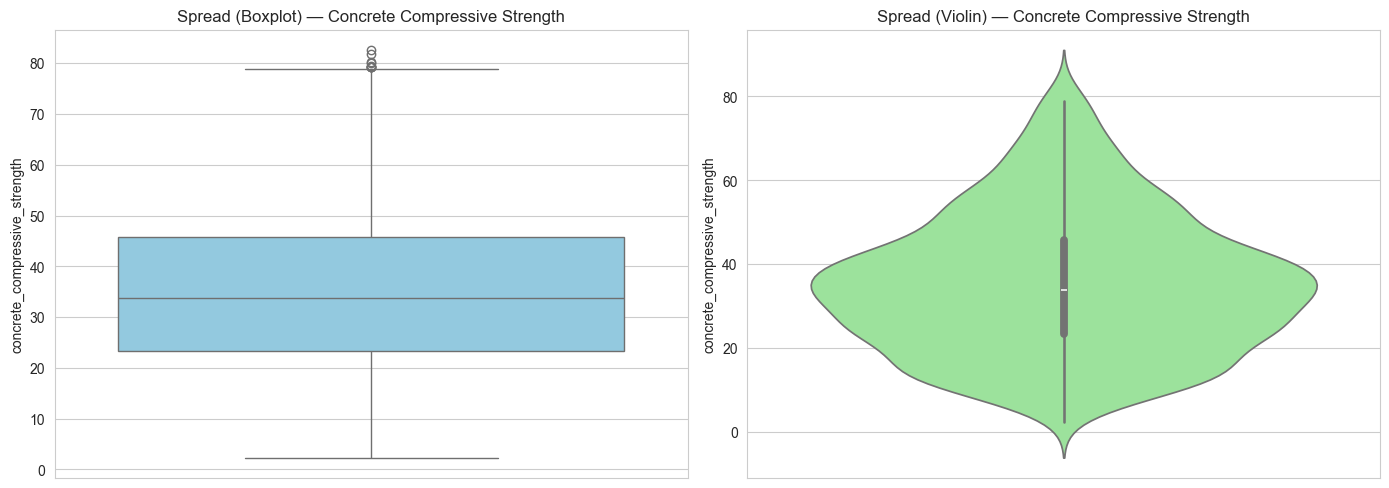

In [10]:
# ============================================================
# CELL 4: SPREAD PLOT FIRST — Target Distribution Before Anything Else
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df[target_col], ax=axes[0], color="skyblue")
axes[0].set_title("Spread (Boxplot) — Concrete Compressive Strength")

sns.violinplot(y=df[target_col], ax=axes[1], color="lightgreen")
axes[1].set_title("Spread (Violin) — Concrete Compressive Strength")

plt.tight_layout()
plt.show()

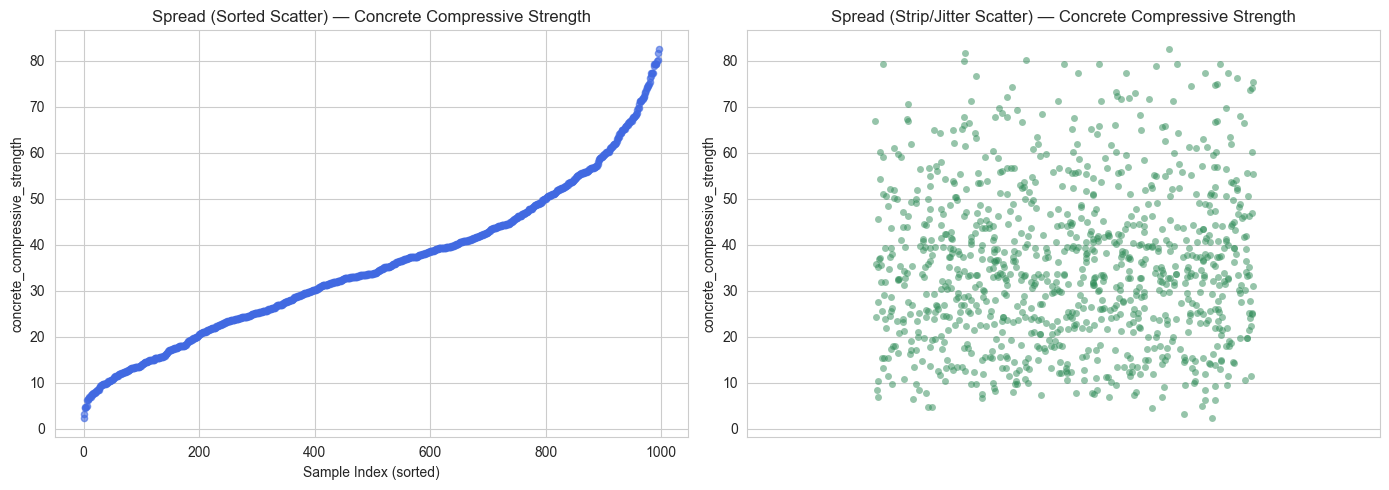

In [11]:
# ============================================================
# CELL 4: SPREAD PLOT FIRST — Target Distribution Before Anything Else
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter of target vs row index — shows spread/range across the dataset
axes[0].scatter(range(len(df)), df[target_col].sort_values().values,
                 alpha=0.6, color="royalblue", s=20)
axes[0].set_title("Spread (Sorted Scatter) — Concrete Compressive Strength")
axes[0].set_xlabel("Sample Index (sorted)")
axes[0].set_ylabel(target_col)

# Scatter of target vs a jittered constant x — shows density/spread as a strip plot
sns.stripplot(y=df[target_col], ax=axes[1], color="seagreen", alpha=0.5, jitter=0.3)
axes[1].set_title("Spread (Strip/Jitter Scatter) — Concrete Compressive Strength")

plt.tight_layout()
plt.show()

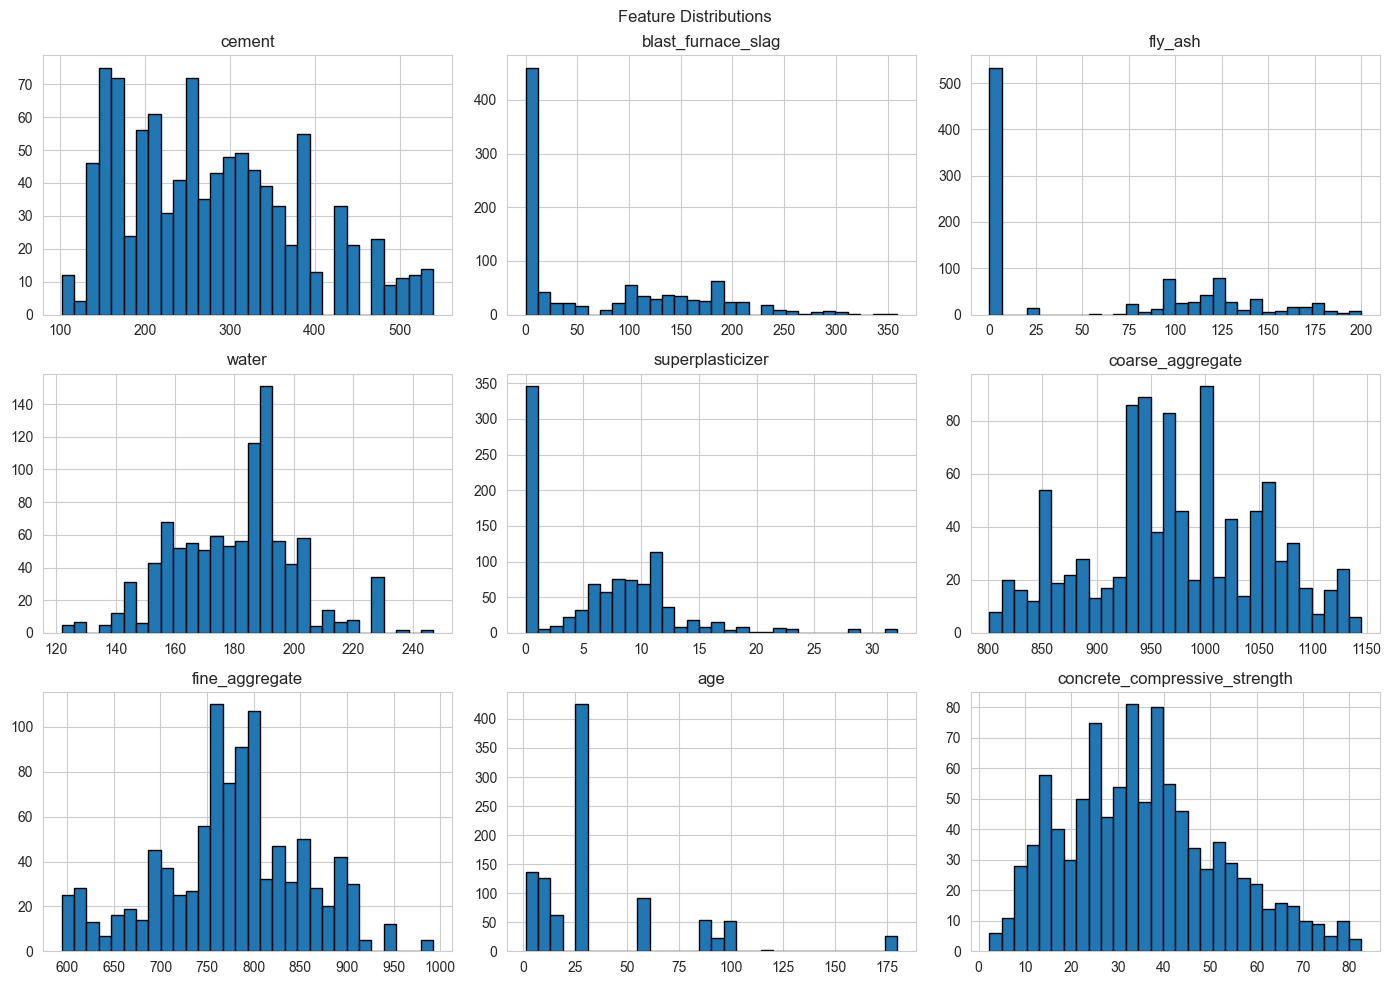

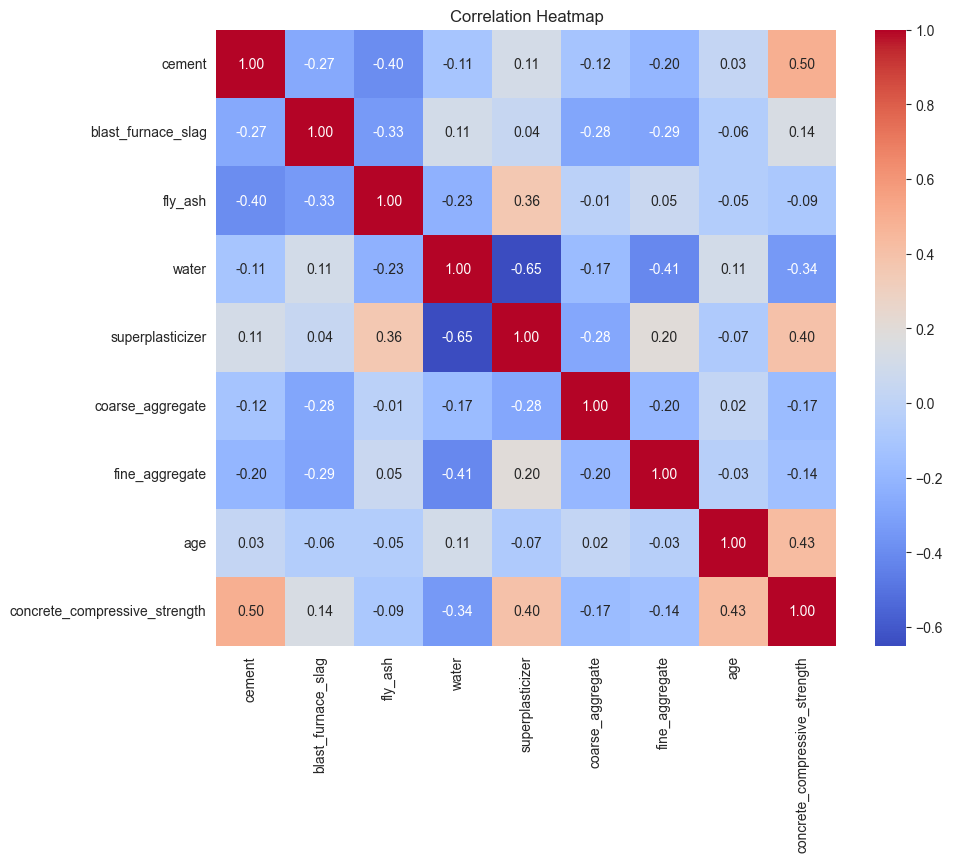

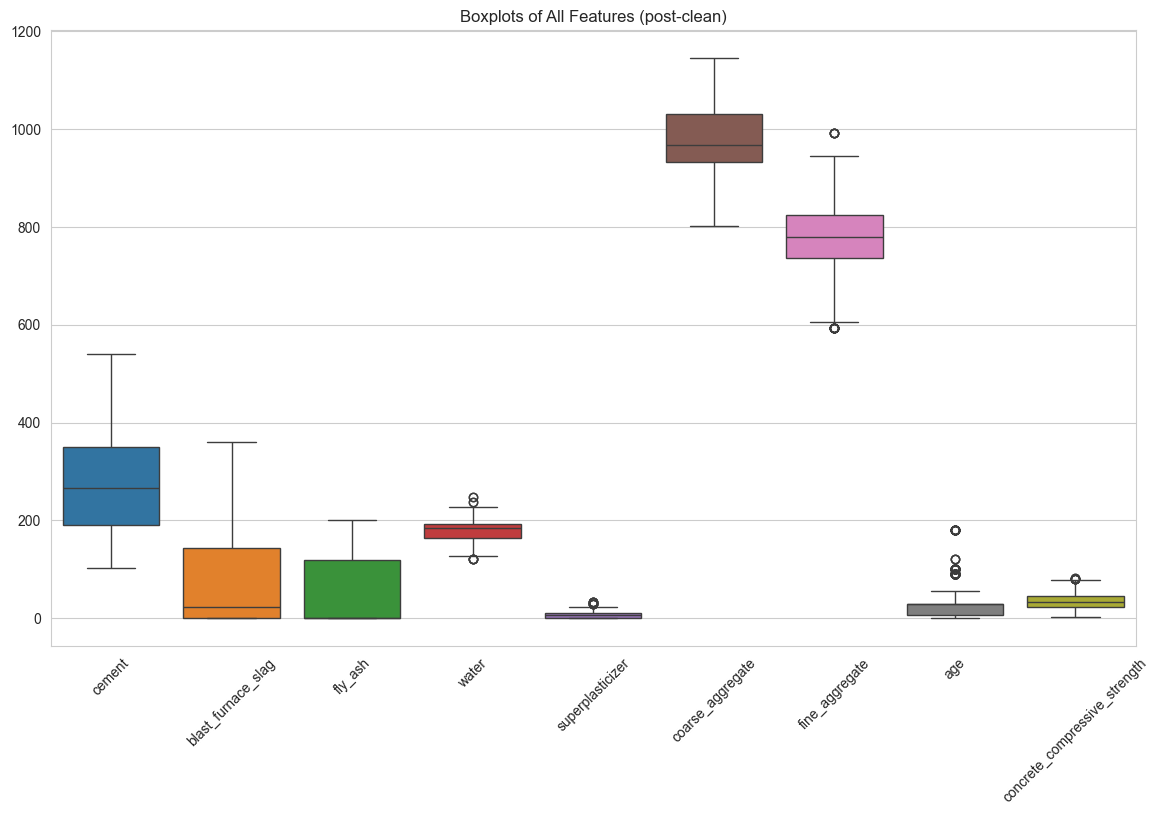

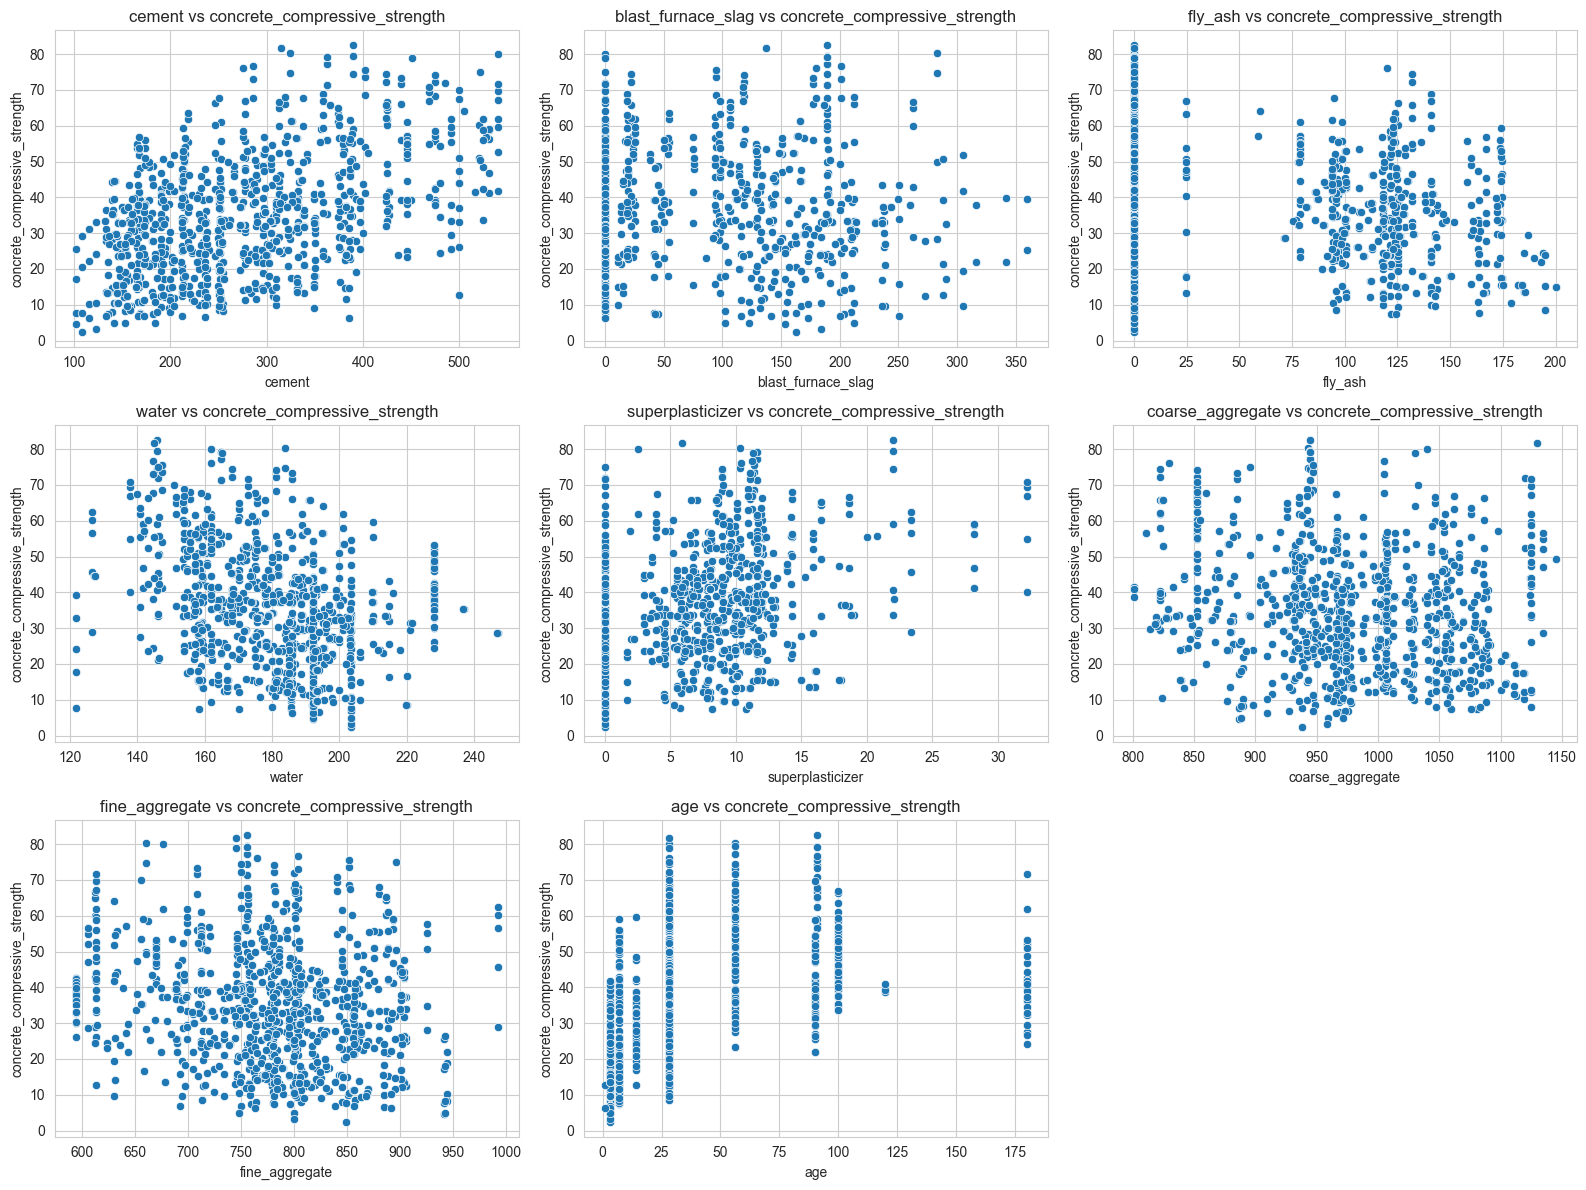

In [6]:
# ============================================================
# CELL 5: Remaining Visualizations
# ============================================================
df.hist(figsize=(14, 10), bins=30, edgecolor="black")
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(14, 8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplots of All Features (post-clean)")
plt.show()

features = [c for c in df.columns if c != target_col]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.scatterplot(x=df[col], y=df[target_col], ax=axes[i])
    axes[i].set_title(f"{col} vs {target_col}")
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# CELL 6: Train-Test Split + Scaling
# ============================================================
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (797, 8)
X_test shape: (200, 8)


In [14]:
# ============================================================
# CELL 7: Evaluation Function
# ============================================================

results = []

def evaluate_model(model_name, model):

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # Store results
    results.append({
        "Model": model_name,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae
    })

    # Print results
    print(f"\n{'='*50}")
    print(f"Model      : {model_name}")
    print(f"Train R²   : {train_r2:.4f}")
    print(f"Test R²    : {test_r2:.4f}")
    print(f"Test RMSE  : {test_rmse:.4f}")
    print(f"Test MAE   : {test_mae:.4f}")
    print(f"{'='*50}")

In [15]:
# ============================================================
# CELL 8: Linear Regression
# ============================================================
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
evaluate_model("Linear Regression", model_lr)


Model      : Linear Regression
Train R²   : 0.7120
Test R²    : 0.6477
Test RMSE  : 9.5593
Test MAE   : 7.2052


In [17]:
# ============================================================
# CELL 9: Ridge
# ============================================================

model_ridge = Ridge()
model_ridge.fit(X_train_scaled, y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [12]:
evaluate_model("Ridge", model_ridge)


Model      : Ridge
Train R²   : 0.7120
Test R²    : 0.6474
Test RMSE  : 9.5633
Test MAE   : 7.2082


In [18]:
# ============================================================
# CELL 10: Lasso
# ============================================================
model_lasso = Lasso()
model_lasso.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [14]:
evaluate_model("Lasso", model_lasso)


Model      : Lasso
Train R²   : 0.6711
Test R²    : 0.5923
Test RMSE  : 10.2833
Test MAE   : 7.9646


In [19]:
# ============================================================
# CELL 11: ElasticNet
# ============================================================
model_en = ElasticNet()
model_en.fit(X_train_scaled, y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [16]:
evaluate_model("ElasticNet", model_en)


Model      : ElasticNet
Train R²   : 0.5999
Test R²    : 0.5386
Test RMSE  : 10.9395
Test MAE   : 8.7469


In [20]:
# ============================================================
# CELL 12: Decision Tree
# ============================================================
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train_scaled, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [18]:
evaluate_model("Decision Tree", model_dt)


Model      : Decision Tree
Train R²   : 0.9962
Test R²    : 0.8066
Test RMSE  : 7.0833
Test MAE   : 4.4483


In [21]:
# ============================================================
# CELL 13: Random Forest
# ============================================================
model_rf = RandomForestRegressor(random_state=42, n_estimators=200)
model_rf.fit(X_train_scaled, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
evaluate_model("Randomforest Regression", model_rf)


Model      : Randomforest Regression
Train R²   : 0.9852
Test R²    : 0.8951
Test RMSE  : 5.2160
Test MAE   : 3.5834


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)



,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.03, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [30]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

model_gb = grid.best_estimator_

evaluate_model("GradientBoot Regression", model_gb)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 0.8}
Best CV Score: 0.9341740470450922

Model      : GradientBoot Regression
Train R²   : 0.9901
Test R²    : 0.9403
Test RMSE  : 3.9350
Test MAE   : 2.7370


In [31]:
# ============================================================
# CELL 16: SVR
# ============================================================
model_svr = SVR()
model_svr.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [32]:
evaluate_model("svr", model_svr)


Model      : svr
Train R²   : 0.7296
Test R²    : 0.6789
Test RMSE  : 9.1261
Test MAE   : 6.9226


In [33]:
# AdaBoost
model_ada = AdaBoostRegressor(random_state=42)
model_ada.fit(X_train_scaled, y_train)


,estimator,None
,n_estimators,50
,learning_rate,1.0
,loss,'linear'
,random_state,42


In [34]:
evaluate_model("AdaBoost", model_ada)


Model      : AdaBoost
Train R²   : 0.8312
Test R²    : 0.7889
Test RMSE  : 7.3997
Test MAE   : 5.9475


In [35]:
# KNN
model_knn = KNeighborsRegressor()
model_knn.fit(X_train_scaled, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [36]:
evaluate_model("KNN", model_knn)


Model      : KNN
Train R²   : 0.8527
Test R²    : 0.7630
Test RMSE  : 7.8414
Test MAE   : 6.1061


              Feature  Importance
7                 age    0.350844
0              cement    0.302888
3               water    0.106348
1  blast_furnace_slag    0.084098
4    superplasticizer    0.073223
6      fine_aggregate    0.040256
5    coarse_aggregate    0.026843
2             fly_ash    0.015499


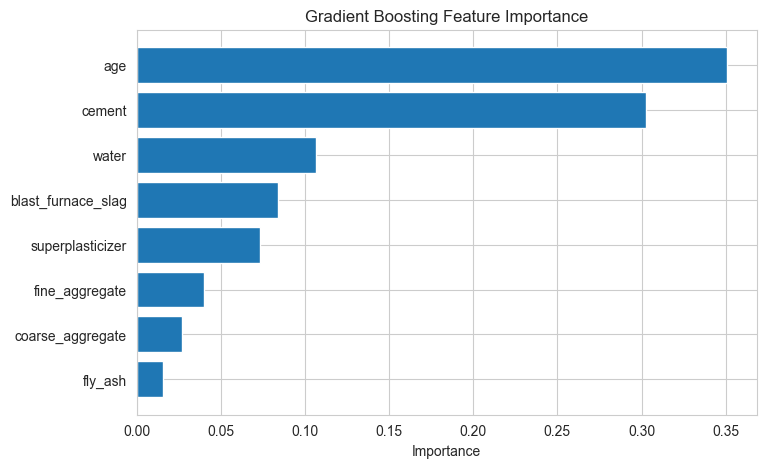

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_gb.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Gradient Boosting Feature Importance")
plt.show()

In [38]:
# ============================================================
# CELL 18: Compare All + Pick Best Model
# ============================================================
# ============================================================
# CELL 18: Compare All Models + Select Best Model
# ============================================================

results_df = (
    pd.DataFrame(results)
    .sort_values(by="Test_R2", ascending=False)
    .reset_index(drop=True)
)

print(results_df)

# Best model name from results
best_model_name = results_df.iloc[0]["Model"]

# Dictionary of trained models
model_lookup = {
    "Linear Regression": model_lr,
    "Ridge": model_ridge,
    "Lasso": model_lasso,
    "ElasticNet": model_en,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "GradientBoot Regression": model_gb,
    "AdaBoost": model_ada,
    "SVR": model_svr,
    "KNN": model_knn
}

# Get best trained model
best_model = model_lookup[best_model_name]

print(f"\nBest Model : {best_model_name}")
print(best_model)

                     Model  Train_R2   Test_R2  Test_RMSE  Test_MAE
0  GradientBoot Regression  0.990068  0.940304   3.935033  2.736955
1  GradientBoot Regression  0.990068  0.940304   3.935033  2.736955
2  GradientBoot Regression  0.990068  0.940304   3.935033  2.736955
3                 AdaBoost  0.831222  0.788908   7.399653  5.947495
4                      KNN  0.852660  0.762951   7.841429  6.106140
5                      svr  0.729573  0.678916   9.126104  6.922623
6        Linear Regression  0.712036  0.647707   9.559336  7.205156

Best Model : GradientBoot Regression
GradientBoostingRegressor(max_depth=4, min_samples_leaf=2, n_estimators=300,
                          random_state=42, subsample=0.8)


Best Model: GradientBoot Regression
Train R2: 0.9901 | Test R2: 0.9403
Train RMSE: 1.6873 | Test RMSE: 3.9350
Train MAE: 1.0268 | Test MAE: 2.7370


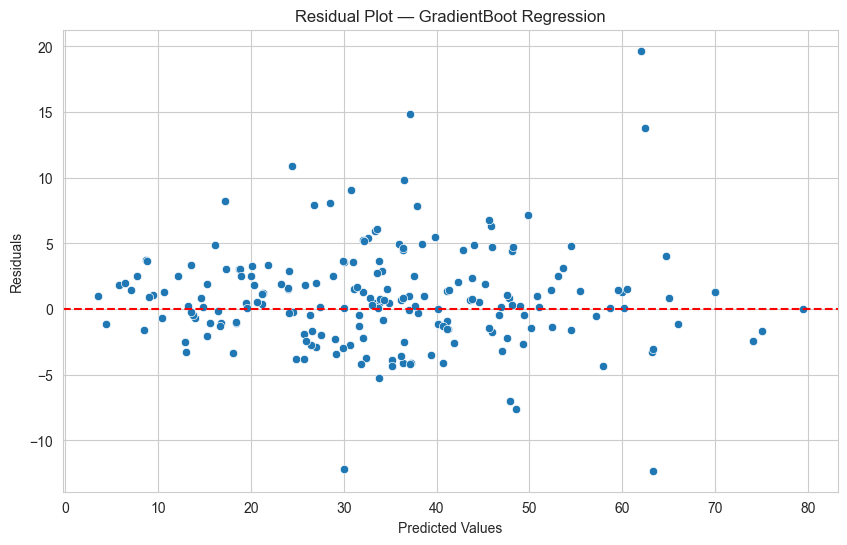

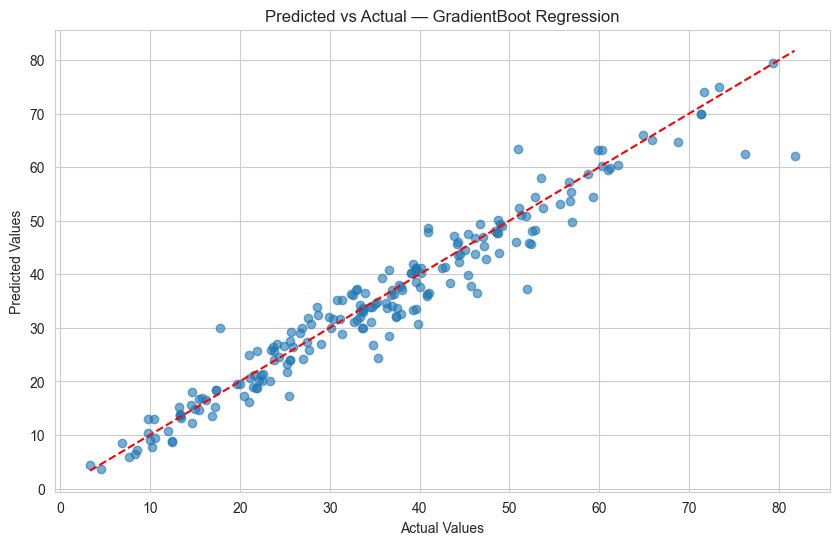


--- VERDICT ---
Good fit: Train R2 (0.9901) and Test R2 (0.9403) are close and reasonably high


In [39]:
# ============================================================
# CELL 19: Evaluate Best Model — Overfitting/Underfitting Check
# ============================================================
y_pred_train = best_model.predict(X_train_scaled)
y_pred_test = best_model.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"Best Model: {best_model_name}")
print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f} | Test MAE: {test_mae:.4f}")

residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_test, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot — {best_model_name}")
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.show()

r2_gap = train_r2 - test_r2
print("\n--- VERDICT ---")
if r2_gap > 0.15:
    print(f"Overfitting: Train R2 ({train_r2:.4f}) >> Test R2 ({test_r2:.4f}), gap = {r2_gap:.4f}")
elif train_r2 < 0.6 and test_r2 < 0.6:
    print(f"Underfitting: Both R2 low")
else:
    print(f"Good fit: Train R2 ({train_r2:.4f}) and Test R2 ({test_r2:.4f}) are close and reasonably high")

In [33]:
# ============================================================
# CELL 20: Test on 5 Random Rows — Absolute Error AND % Error
# ============================================================
sample_idx = np.random.choice(X_test.index, size=5, replace=False)
X_sample = X_test.loc[sample_idx]
y_sample_actual = y_test.loc[sample_idx]
X_sample_scaled = scaler.transform(X_sample)
y_sample_pred = best_model.predict(X_sample_scaled)

comparison_df = pd.DataFrame({
    "Actual": y_sample_actual.values,
    "Predicted": y_sample_pred,
})
comparison_df["Abs Error (MPa)"] = (comparison_df["Predicted"] - comparison_df["Actual"]).abs()
comparison_df["Error %"] = (comparison_df["Abs Error (MPa)"] / comparison_df["Actual"]) * 100

print(comparison_df)
print("\nNote: % error looks large on low-strength samples even when the")
print("absolute MPa miss is small — check the 'Abs Error (MPa)' column too.")

   Actual  Predicted  Abs Error (MPa)    Error %
0   31.42  28.900325         2.519675   8.019334
1   40.86  36.386640         4.473360  10.948017
2   11.96  10.659643         1.300357  10.872553
3   50.77  46.012704         4.757296   9.370289
4   27.63  31.850758         4.220758  15.275998

Note: % error looks large on low-strength samples even when the
absolute MPa miss is small — check the 'Abs Error (MPa)' column too.


In [34]:
# ============================================================
# CELL 21: Manual Input Prediction
# ============================================================
print("Enter values for the following features:")
cement = float(input("Cement: "))
blast_furnace_slag = float(input("Blast Furnace Slag: "))
fly_ash = float(input("Fly Ash: "))
water = float(input("Water: "))
superplasticizer = float(input("Superplasticizer: "))
coarse_aggregate = float(input("Coarse Aggregate: "))
fine_aggregate = float(input("Fine Aggregate: "))
age = float(input("Age: "))

manual_input = pd.DataFrame([{
    "cement": cement, "blast_furnace_slag": blast_furnace_slag, "fly_ash": fly_ash,
    "water": water, "superplasticizer": superplasticizer,
    "coarse_aggregate": coarse_aggregate, "fine_aggregate": fine_aggregate, "age": age
}])[X.columns]

manual_input_scaled = scaler.transform(manual_input)
predicted_strength = best_model.predict(manual_input_scaled)[0]
print(f"\nPredicted Concrete Compressive Strength: {predicted_strength:.4f} MPa")

Enter values for the following features:


Cement:  45
Blast Furnace Slag:  446
Fly Ash:  56
Water:  646
Superplasticizer:  464
Coarse Aggregate:  55
Fine Aggregate:  54
Age:  54



Predicted Concrete Compressive Strength: 38.3867 MPa


In [35]:
# ============================================================
# CELL 22: Save Model and Scaler
# ============================================================
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Saved best_model.pkl and scaler.pkl successfully.")

Saved best_model.pkl and scaler.pkl successfully.


In [36]:
error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": best_model.predict(X_test_scaled)
})

error_df["Abs Error"] = abs(error_df["Actual"] - error_df["Predicted"])
error_df["Error %"] = error_df["Abs Error"] / error_df["Actual"] * 100

# Show the largest errors
error_df.sort_values("Abs Error", ascending=False).head(20)

,Actual,Predicted,Abs Error,Error %
359,81.75,62.073467,19.676533,24.069153
456,52.01,37.170383,14.839617,28.532238
382,76.24,62.435973,13.804027,18.106017
365,51.02,63.336337,12.316337,24.140215
213,17.84,30.040113,12.200113,68.386284
453,35.36,24.459097,10.900903,30.828346
411,46.39,36.526976,9.863024,21.261099
890,39.84,30.797963,9.042037,22.695875
198,25.48,17.246968,8.233032,32.311743
423,36.56,28.499055,8.060945,22.048538


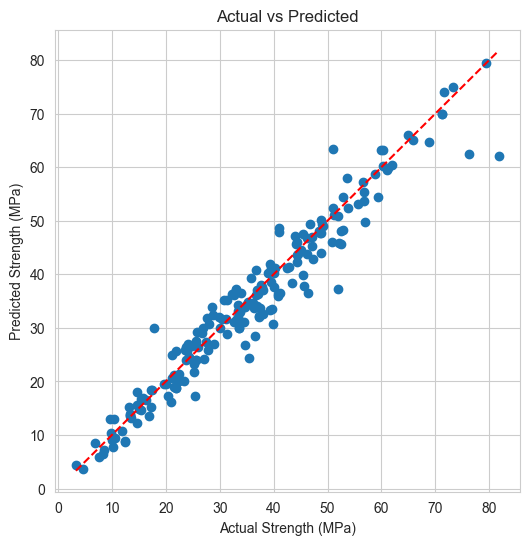

In [37]:
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Actual vs Predicted")
plt.show()

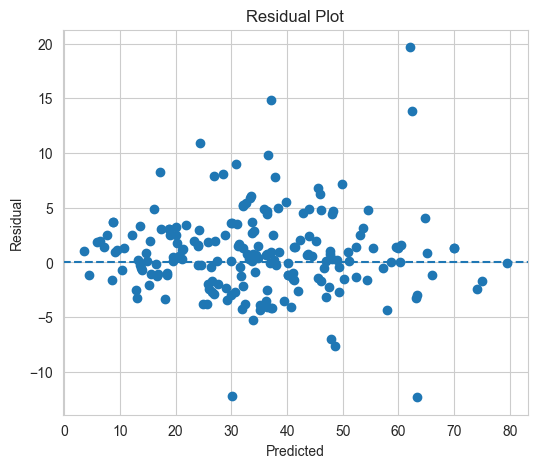

In [38]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [39]:
error_df[error_df["Abs Error"] > 8]

,Actual,Predicted,Abs Error,Error %
453,35.36,24.459097,10.900903,30.828346
382,76.24,62.435973,13.804027,18.106017
198,25.48,17.246968,8.233032,32.311743
365,51.02,63.336337,12.316337,24.140215
890,39.84,30.797963,9.042037,22.695875
359,81.75,62.073467,19.676533,24.069153
411,46.39,36.526976,9.863024,21.261099
456,52.01,37.170383,14.839617,28.532238
213,17.84,30.040113,12.200113,68.386284
423,36.56,28.499055,8.060945,22.048538


In [40]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000
mean,279.466098,74.112237,55.981946,180.501805,6.410030,973.150552,776.327482,36.361083,35.478405
std,104.265701,86.534529,64.271338,20.610748,5.962502,78.303511,77.988440,36.749587,16.776466
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,190.700000,0.000000,0.000000,164.900000,0.000000,932.000000,737.000000,7.000000,23.400000
50%,266.000000,22.000000,0.000000,184.000000,6.700000,968.000000,780.100000,28.000000,33.730000
75%,350.000000,144.200000,118.300000,192.000000,10.400000,1030.000000,825.000000,28.000000,45.710000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,180.000000,82.600000


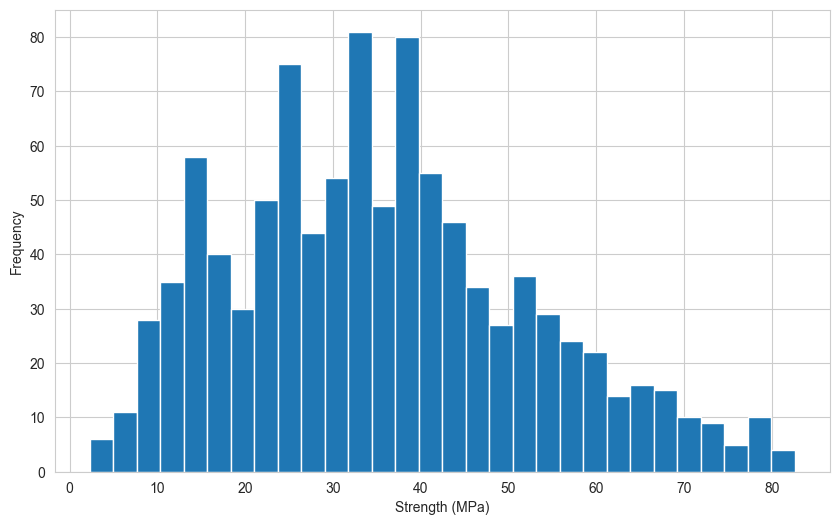

In [41]:
import matplotlib.pyplot as plt

plt.hist(df["concrete_compressive_strength"], bins=30)
plt.xlabel("Strength (MPa)")
plt.ylabel("Frequency")
plt.show()